In [1]:
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import emcee
import ultranest

In [2]:
# Le larghezze esatte derivate dalla stringa Fortran
widths = [1, 3, 5, 5, 5, 1, 3, 4, 1, 14, 12, 13, 1, 10, 1, 2, 13, 11, 1, 3, 1, 13, 12]

nomi_colonne = [
    'cc', 'NZ', 'N', 'Z', 'A', 'skip_1', 'el', 'o', 'skip_2', 
    'mass_excess', 'mass_unc', 'binding', 'skip_3', 'binding_unc', 'skip_4', 
    'B', 'beta_decay', 'beta_unc', 'skip_5', 'atomic_mass_int', 'skip_6', 
    'atomic_mass_dec', 'atomic_mass_unc'
]

# Leggiamo il file (skiprows=39 dovrebbe saltare esattamente tutta l'intestazione testuale)
df = pd.read_fwf('mass_1.mas20.txt', widths=widths, names=nomi_colonne, skiprows=38)

# Rimuoviamo le colonne vuote usate come separatori
df = df.drop(columns=[col for col in df.columns if 'skip' in col])

# se ho il # alla fine del numero in BE, significa che è un numero approssimato, quindi elimino la riga
df = df.replace(r'(\d+)#', np.nan, regex=True)

# Sostituiamo gli asterischi '*' con NaN (Not a Number, lo standard per i dati mancanti)
df = df.replace(r'^\s*\*\s*$', np.nan, regex=True)

df = df.dropna(subset=['binding'])

# Forziamo la conversione in numeri decimali (float) per le colonne che contenevano valori
colonne_numeriche = [
    'mass_excess', 'mass_unc', 'binding', 'binding_unc', 
    'beta_decay', 'beta_unc', 'atomic_mass_dec', 'atomic_mass_unc'
]

for col in colonne_numeriche:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Risultato finale
print(df.head())

    cc  NZ  N  Z  A  el    o   mass_excess    mass_unc     binding  \
0  0.0   0  1  1  2   H  NaN  13135.722895    0.000015  1112.28310   
1  0.0   1  2  1  3   H  NaN  14949.810900    0.000080  2827.26540   
2  NaN  -1  1  2  3  He  NaN  14931.218880    0.000060  2572.68044   
4  0.0   2  3  1  4   H   -n  24621.129000  100.000000  1720.44910   
5  NaN   0  2  2  4  He  NaN   2424.915870    0.000150  7073.91560   

   binding_unc   B   beta_decay   beta_unc  atomic_mass_int  atomic_mass_dec  \
0      0.00020  B-          NaN        NaN                2     14101.777844   
1      0.00030  B-     18.59202    0.00006                3     16049.281320   
2      0.00015  B-          NaN        NaN                3     16029.321970   
4     25.00000  B-  22196.21310  100.00000                4     26431.867000   
5      0.00020  B- -22898.27400  212.13200                4      2603.254130   

   atomic_mass_unc  
0         0.000015  
1         0.000080  
2         0.000060  
4       107.35

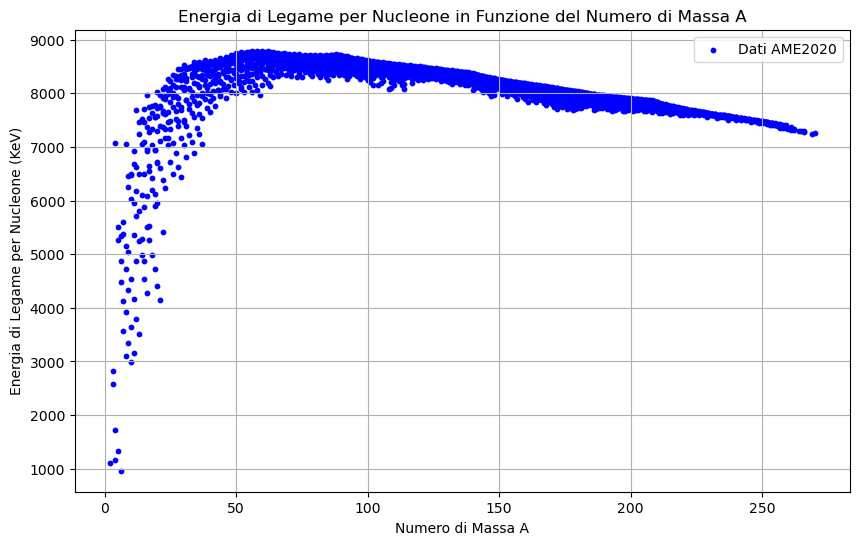

In [3]:
# grafico di BE in funzione di A
plt.figure(figsize=(10, 6))
plt.scatter(df['A'], df['binding'], s=10, color='blue', label='Dati AME2020')
plt.xlabel('Numero di Massa A')
plt.ylabel('Energia di Legame per Nucleone (KeV)')
plt.title('Energia di Legame per Nucleone in Funzione del Numero di Massa A')
plt.legend()
plt.grid()
plt.show()

In [34]:
# inferenza bayesiana con ultranest
def prior(cube):
    # cube è un array di valori tra 0 e 1, che dobbiamo trasformare nei nostri parametri
    a = 10 * cube[0] * 10 
    b = 10.0 * cube[1] * 15 
    c = cube[2] * 2 
    d =  10 * cube[3] * 25 
    sigma_th = cube[4] * 10
    return [a, b, c, d, sigma_th]

def prior_2(cube):
    a = 10 * cube[0] * 10 
    b = 10.0 * cube[1] * 15 
    c = cube[2] * 2 
    d =  10 * cube[3] * 25 
    delta_0 = cube[4] * 30  
    a_st = 10 + cube[5] * 30
    a_w = cube[6] * 10
    sigma_th = cube[7] * 10
    
    return [a, b, c, d, delta_0, a_st, a_w, sigma_th]

def model(A, Z, N, a, b, c, d):
    return a * A - b * A**(2/3) - c*(Z* (Z - 1) / (A**(1/3))) - d * (N-Z)**2 / A

def model_2(A, Z, N, a, b, c, d, delta_0, a_st, a_w):
    delta = np.zeros_like(A, dtype=float)
    
    # Maschere booleane per pari-pari e dispari-dispari
    pari_pari = (N % 2 == 0) & (Z % 2 == 0)
    dispari_dispari = (N % 2 == 1) & (Z % 2 == 1)
    pari_dispari = (N%2 ==0) & (Z%2 == 1) | (N%2 == 1) & (Z%2 == 0)
    
    # Calcolo massivo
    delta_term = delta_0 / A**(3/4)
    
    # Assegnazione
    delta[pari_pari] = delta_term[pari_pari]
    delta[dispari_dispari] = -delta_term[dispari_dispari]
    delta[pari_dispari] = 0
    
    return a * A - b * A**(2/3) - c*(Z* (Z - 1) / (A**(1/3))) - d * (N-Z)**2 / A + delta + a_st*(N-Z)**2 / A**(4/3)+ a_w *np.abs(N-Z)/A

def log_likelihood(params):
    a, b, c, d, sigma_th = params
    A = df['A'].values
    Z = df['Z'].values
    N = df['N'].values
    BE_obs = (df['binding'].values /1000)*A  # Convertiamo da KeV a MeV
    BE_model = model(A, Z, N, a, b, c, d)
    sigma_exp = (df['binding_unc'].values / 1000) * A  # in MeV
    sigma_tot = np.sqrt(sigma_exp**2 + sigma_th**2)
    
    # Log-likelihood usando l'incertezza totale
    logL = -0.5 * np.sum(((BE_obs - BE_model) / sigma_tot)**2 + np.log(2 * np.pi * sigma_tot**2))
    return logL

def log_likelihood_2(params):
    a, b, c, d, delta_0, a_st, a_w, sigma_th = params
    A = df['A'].values
    Z = df['Z'].values
    N = df['N'].values
    BE_obs = (df['binding'].values /1000)*A  # Convertiamo da KeV a MeV
    BE_model = model_2(A, Z, N, a, b, c, d, delta_0, a_st, a_w)
    sigma_exp = (df['binding_unc'].values / 1000) * A  # in MeV
    sigma_tot = np.sqrt(sigma_exp**2 + sigma_th**2)
    
    # Log-likelihood usando l'incertezza totale
    logL = -0.5 * np.sum(((BE_obs - BE_model) / sigma_tot)**2 + np.log(2 * np.pi * sigma_tot**2))
    return logL

In [5]:
#run ultranest
sampler = ultranest.ReactiveNestedSampler(['a', 'b', 'c', 'd', 'sigma_th'], log_likelihood, prior)
result = sampler.run(min_num_live_points=600, dKL=np.inf, min_ess=200)
print(result)

[ultranest] Sampling 600 live points from prior ...


[ultranest] Explored until L=-7e+03  993.85 [-6995.0375..-6995.0364]*| it/evals=23048/68457 eff=33.9655% N=600     0   0  0   
[ultranest] Likelihood function evaluations: 68457
[ultranest]   logZ = -7032 +- 0.1719
[ultranest] Effective samples strategy satisfied (ESS = 2924.7, need >200)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.04 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.27, need <0.5)
[ultranest]   logZ error budget: single: 0.24 bs:0.17 tail:0.20 total:0.27 required:<0.50
[ultranest] done iterating.
{'niter': 23649, 'logz': np.float64(-7031.545155263317), 'logzerr': np.float64(0.42139196953195257), 'logz_bs': np.float64(-7031.547298733661), 'logz_single': np.float64(-7031.545155263317), 'logzerr_tail': np.float64(0.20429856246300915), 'logzerr_bs': np.float64(0.36855568013743323), 'ess': np.float64(2924.686822661937), 'H': np.float64(35.02172314786276), 'Herr': np.float64(0.16243358756017365), 'posterior': {'mean

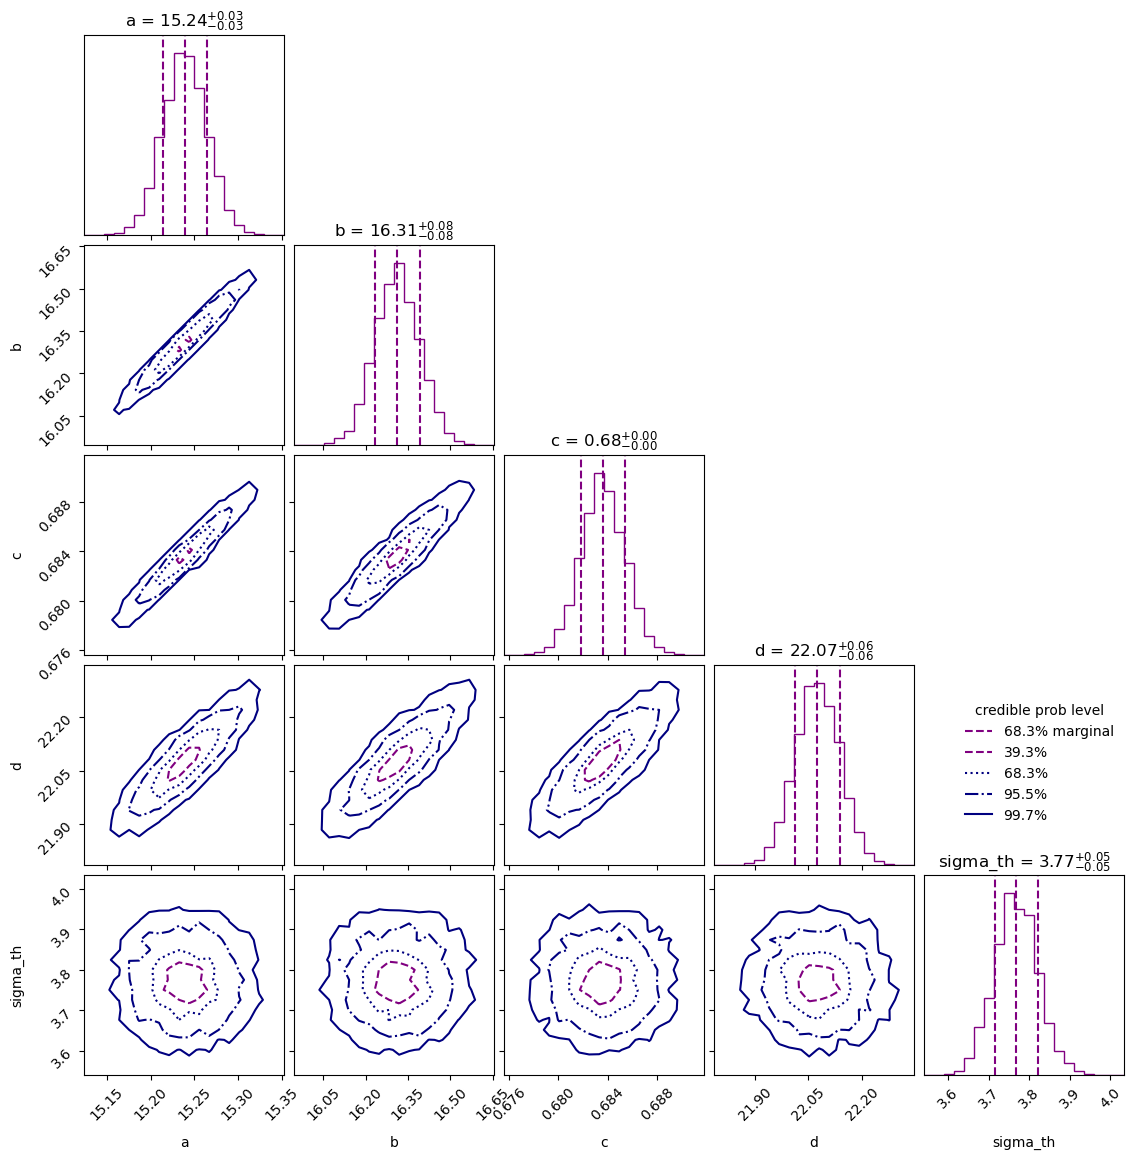

In [6]:
cornerplot = sampler.plot_corner()

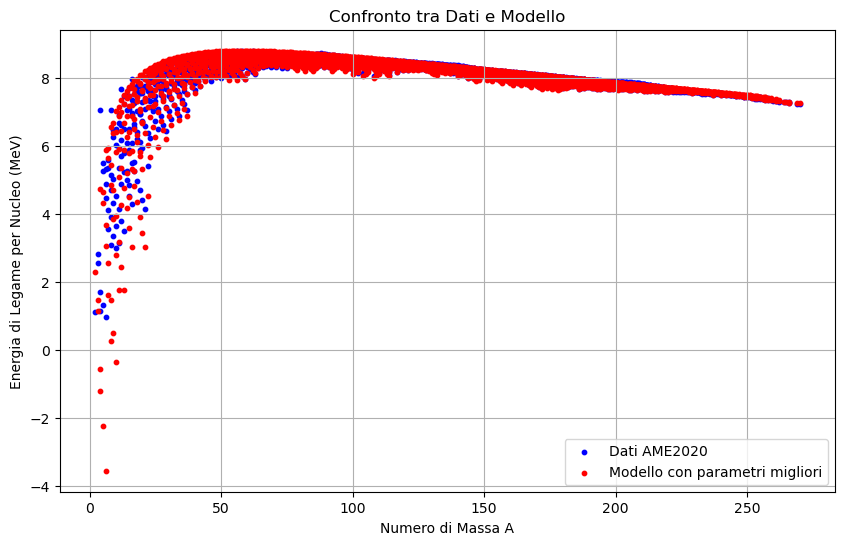

In [7]:
# calcolo il BE con i parametri migliori per ogni nucleo e confronto con i dati
a_best, b_best, c_best, d_best, sigma_th_best = result['posterior']['mean']
A = df['A'].values
Z = df['Z'].values
N = df['N'].values
BE_obs = (df['binding'].values /1000) # Convertiamo da KeV a MeV
BE_model = model(A, Z, N, a_best, b_best, c_best, d_best)/A   
plt.figure(figsize=(10, 6))
plt.scatter(A, BE_obs, s=10, color='blue', label='Dati AME2020')
plt.scatter(A, BE_model, s=10, color='red', label='Modello con parametri migliori')
plt.xlabel('Numero di Massa A')
plt.ylabel('Energia di Legame per Nucleo (MeV)')
plt.title('Confronto tra Dati e Modello')
plt.legend()
plt.grid()
plt.show()

In [33]:
#run ultranest
sampler2 = ultranest.ReactiveNestedSampler(['a', 'b', 'c', 'd',  'delta_0', 'a_st', 'a_w', 'sigma_th'], log_likelihood_2, prior_2)
result2 = sampler2.run(min_num_live_points=400, dKL=np.inf, min_ess=100)
print(result2)

[ultranest] Sampling 400 live points from prior ...


KeyboardInterrupt: 

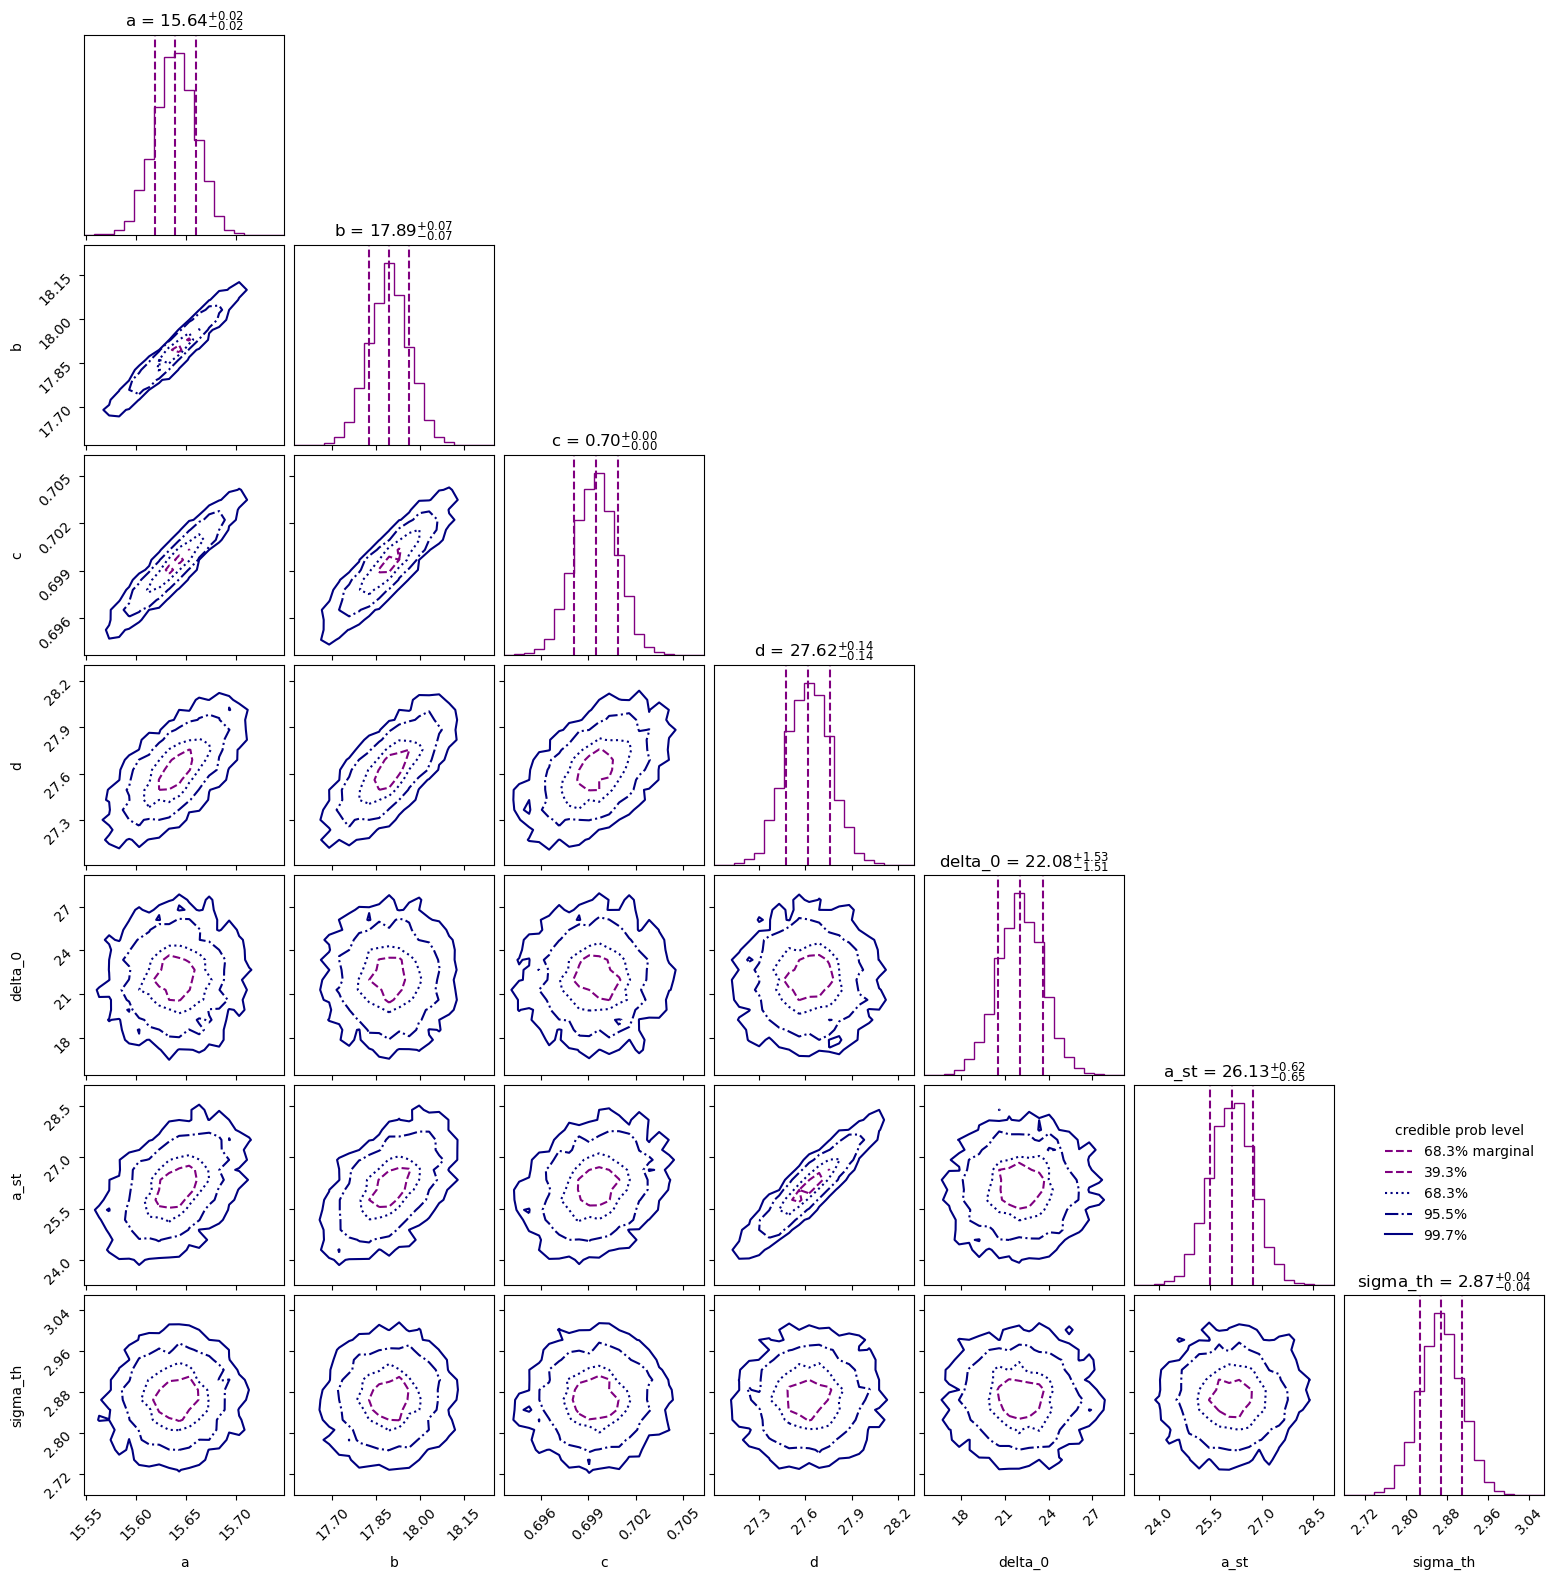

In [ ]:
cornerplot2 = sampler2.plot_corner()

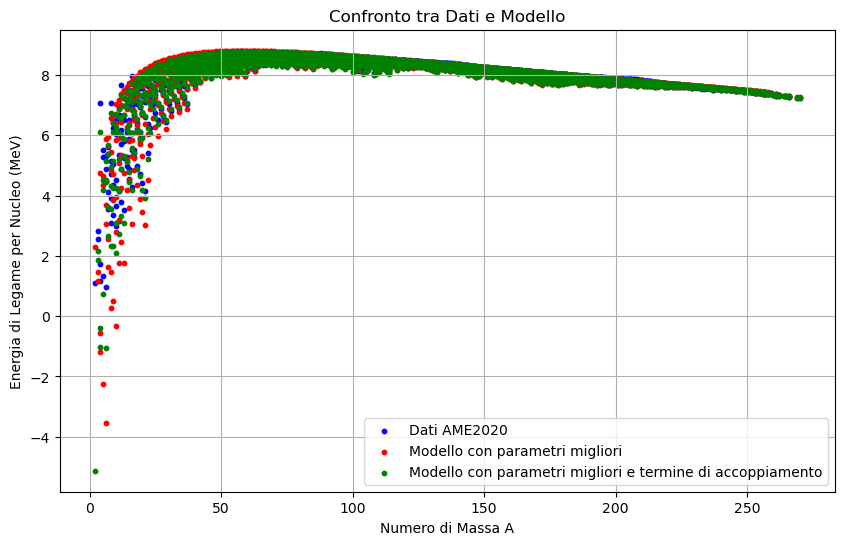

In [ ]:
# calcolo il BE con i parametri migliori per ogni nucleo e confronto con i dati
a_best2, b_best2, c_best2, d_best2,  delta_0_best2, a_st_best2, a_w_best2, sigma_th_best2 = result2['posterior']['mean']
A = df['A'].values
Z = df['Z'].values
N = df['N'].values
BE_obs = (df['binding'].values /1000) # Convertiamo da KeV a MeV
BE_model1 = model(A, Z, N, a_best, b_best, c_best, d_best)/A
BE_model2 = model_2(A, Z, N, a_best2, b_best2, c_best2, d_best2, delta_0_best2, a_st_best2, a_w_best2)/A   
plt.figure(figsize=(10, 6))
plt.scatter(A, BE_obs, s=10, color='blue', label='Dati AME2020')
plt.scatter(A, BE_model1, s=10, color='red', label='Modello con parametri migliori')
plt.scatter(A, BE_model2, s=10, color='green', label='Modello con parametri migliori e termine di accoppiamento')
plt.xlabel('Numero di Massa A')
plt.ylabel('Energia di Legame per Nucleo (MeV)')
plt.title('Confronto tra Dati e Modello')
plt.legend()
plt.grid()
plt.show()

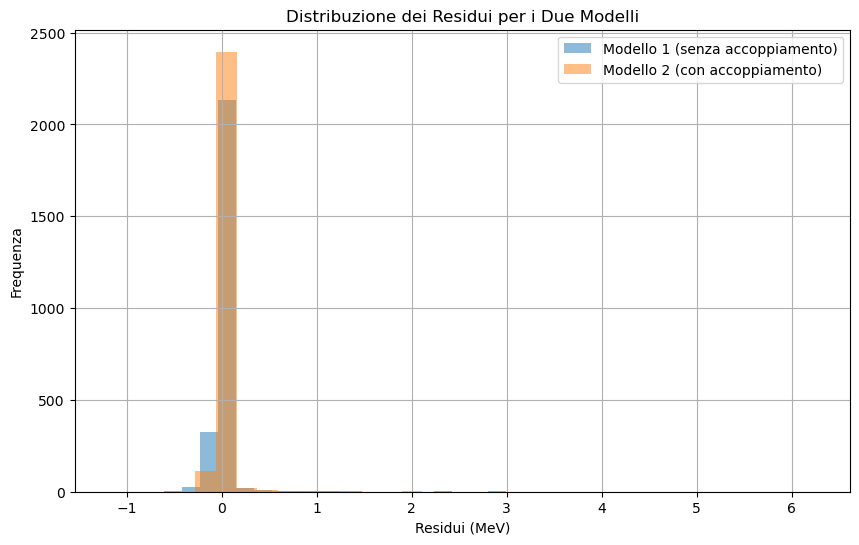

In [ ]:
# confronto tra i due modelli
residui_model1 = BE_obs - BE_model1
residui_model2 = BE_obs - BE_model2
plt.figure(figsize=(10, 6))
plt.hist(residui_model1, bins=30, alpha=0.5, label='Modello 1 (senza accoppiamento)')
plt.hist(residui_model2, bins=30, alpha=0.5, label='Modello 2 (con accoppiamento)')
plt.xlabel('Residui (MeV)')
plt.ylabel('Frequenza')
plt.title('Distribuzione dei Residui per i Due Modelli')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# confronto bayesiano tra i due modelli usando il Bayes factor
logZ1 = result['logz']
logZ2 = result2['logz']
bayes_factor = logZ2 - logZ1
print(f"Bayes Factor (Modello 2 vs Modello 1): {bayes_factor:.2f}")

Bayes Factor (Modello 2 vs Modello 1): 692.39
